# Evaluate **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [1]:
from pathlib import Path
import os
import textwrap
import sys

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BlabladorParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    ParaphrasingEvaluator,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
)

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025/ 04.07.2025 as an example.

In [2]:
path2datasets = (
    Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
)
data_category = "News"  # This is used for plot titles in the notebook
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
# file_name = "cnn_230625"    # USA attacks Iran
file_name = "cnn_040725"  # Dalai Lama
original_text = open(path2datasets / f"{file_name}.txt").read()

print(textwrap.fill(original_text, width=80))

  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an increasingly powerful Beijing has
become ever more assertive in suppressing it.  As his 90th birthday approaches
this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism
worldwide is bracing for a final showdown with Beijing: the battle over who will
control his reincarnation.  On Wednesday, the Dalai Lama announced that he will
have a successor after his death, and that his office will have the sole
authority to identify his reincarnation.  “I am affirming that the institution
of the Dalai Lama will continue,” the Nobel Peace laureate said in a video
message to religious elders gathering in Dharamshala, India, where he has found
refuge since Chinese communist troops put down an armed uprising in his
mountainous homeland in 1959.  The cycle of rebirth lies at the core 

## Naive Approach

In [3]:
ollama_version = "mistral:7b"  # "default:latest"
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    # "Blablador": BlabladorParaphraser(
    #     model_id="1 - Llama3 405 the best general model and big context size"
    # ),
    "Ollama": OllamaParaphraser(model_id=ollama_version),
}
if "Blablador" in paraphrasers.keys():
    print(
        "Available Blablador models:\n",
        paraphrasers["Blablador"]._get_available_models(verbose=False),
    )

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [4]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the text above and output only the paraphrased version.",
    "For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).",
    "For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "For the text above: Paraphrase the sentence using the same tone as the original with approximately the same number of words.",
    "For the text above: Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence.",
]

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [5]:
models = {
    "text_extractor": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
    "text_generator": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [6]:
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [7]:
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [8]:
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Evaluating the Approaches

In [9]:
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
    }
)
paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
)
df, extremest_paraphrases = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
display(df)

Evaluating Paraphrasers:  37%|███▋      | 13/35 [03:58<10:57, 29.88s/it]ERROR:genai_detection.paraphrasing.paraphraser:[ERROR] Paraphraser 'Ollama' with prompt 'For the text above: Paraphrase the sentence using the same tone as the original with approximately the same number of words.' failed: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>
Evaluating Paraphrasers:  46%|████▌     | 16/35 [08:38<20:52, 65.92s/it]ERROR:genai_detection.paraphrasing.paraphraser:[ERROR] Paraphraser 'Task' with prompt 'None' failed: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>
Evaluating Paraphrasers:  60%|██████    | 21/35 [12:45<12:43, 54.56s/it]ERROR:genai_detection.paraphrasing.paraphraser:[ERROR] Paraphraser 'Topic' with prompt 'None' failed: <html>
<head><title>504 Gateway Time-out</title></he

Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
1,T5_ChatGPT,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
2,T5_ChatGPT,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
3,T5_ChatGPT,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
4,T5_ChatGPT,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
5,T5_Google_PAWS,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",in a video message to religious elders gatheri...,1.974961e-04,0.068965,0.182648,0.116031,0.130898,0.130898,0.862977,0.741242,0.797491,0.132915,0.925727,distilbert-base-uncased_L5_no-idf_version=0.3....,0.692070,0.104581,0.587489
6,T5_Google_PAWS,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","as his 90th birthday approaches, the dalai lam...",1.307196e-04,0.065755,0.171779,0.129231,0.147239,0.147239,0.899588,0.731755,0.807038,0.151415,0.921985,distilbert-base-uncased_L5_no-idf_version=0.3....,0.702356,0.106383,0.595973
7,T5_Google_PAWS,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","on wednesday, the dalai lama announced that he...",1.088044e-04,0.063837,0.177914,0.129231,0.144172,0.144172,0.895460,0.748429,0.815369,0.157850,0.884371,distilbert-base-uncased_L5_no-idf_version=0.3....,0.700296,0.107398,0.592897
8,T5_Google_PAWS,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,3.577806e-04,0.081167,0.211161,0.148260,0.174962,0.174962,0.901058,0.752705,0.820228,0.140675,0.875828,distilbert-base-uncased_L5_no-idf_version=0.3....,0.698099,0.128827,0.569272
9,T5_Google_PAWS,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h..."

In [10]:
df["paraphrased_text"].values

array(['despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       "in a video message to religious elders gathering in dharamshala, india this week, the dalai lama announced that he will have a successor after his death and will have the only authority to determine his reincarnation. this is a history of the

### Extremest (i.e. best and worst) paraphrases per metric

In [11]:
display(extremest_paraphrases)

,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,...,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta,metric,extreme
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,bleu_score,min
1,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for the better part of the last century, the d...",3.182570e-01,0.470827,0.691235,0.497006,0.611554,...,0.858832,0.863352,0.388078,0.948297,distilbert-base-uncased_L5_no-idf_version=0.3....,0.785296,0.540349,0.244947,bleu_score,max
2,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,meteor_score,min
3,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for the better part of the last century, the d...",3.182570e-01,0.470827,0.691235,0.497006,0.611554,...,0.858832,0.863352,0.388078,0.948297,distilbert-base-uncased_L5_no-idf_version=0.3....,0.785296,0.540349,0.244947,meteor_score,max
4,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge1,min
5,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for the better part of the last century, the d...",3.182570e-01,0.470827,0.691235,0.497006,0.611554,...,0.858832,0.863352,0.388078,0.948297,distilbert-base-uncased_L5_no-idf_version=0.3....,0.785296,0.540349,0.244947,rouge1,max
6,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge2,min
7,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for the better part of the last century, the d...",3.182570e-01,0.470827,0.691235,0.497006,0.611554,...,0.858832,0.863352,0.388078,0.948297,distilbert-base-uncased_L5_no-idf_version=0.3....,0.785296,0.540349,0.244947,rouge2,max
8,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rougeL,min
9,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for the better part of the last century, the d...",3.182

In [ ]:
print("### Extremest (i.e. best and worst) paraphrases per metric")
print("Original text:")
print(textwrap.fill(original_text[:200], width=80), "...")

for index, row in extremest_paraphrases.iterrows():
    print(f"Metric: {row['extreme']} {row['metric']}")
    print(f"Paraphrase by {row['model']}: {row['paraphrased_text']}")
    # print(f"Prompt: {row['prompt']}")
    print("-" * 80)

### Extremest (i.e. best and worst) paraphrases per metric
Original text:
  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an in
Metric: min bleu_score
Paraphrase by T5_ChatGPT: despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.
--------------------------------------------------------------------------------
Metric: max bleu_score
Paraphrase by Ollama: for the better part of the last century, the dalai lama has been a symbol of tibet's struggle for greater freedoms under chinese communist party rule while residing in exile. as his 90th birthday approaches this sunday, the spiritual leader for millions of tibetan buddhism followers worldwide is preparing for a final confrontation with beijing: the conflict over who will control his reincarnation after his 

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_model_radar_chart_20250718_150305.png


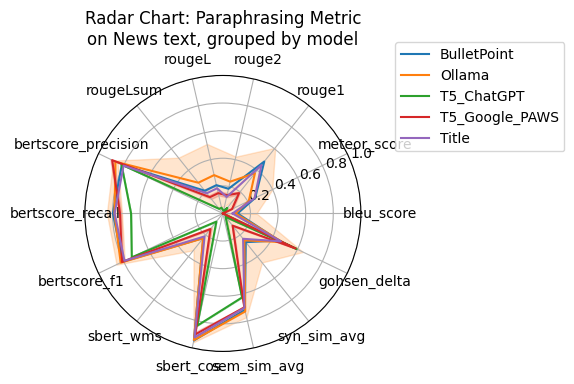

In [13]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="model"
)

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1560: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_prompt_radar_chart_20250718_150305.png


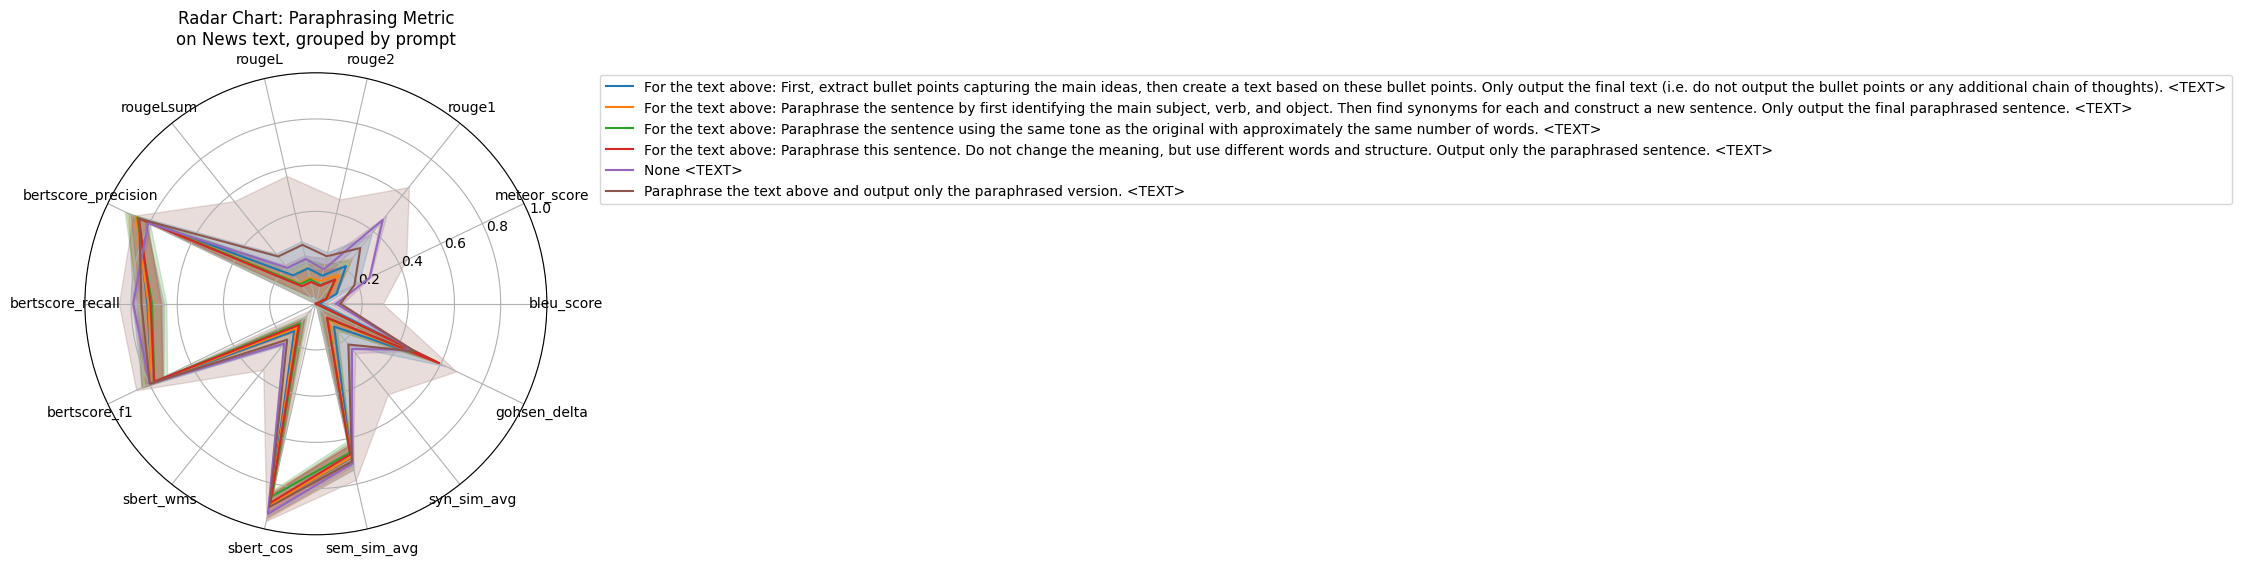

In [14]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="prompt"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_model_20250718_150305.png


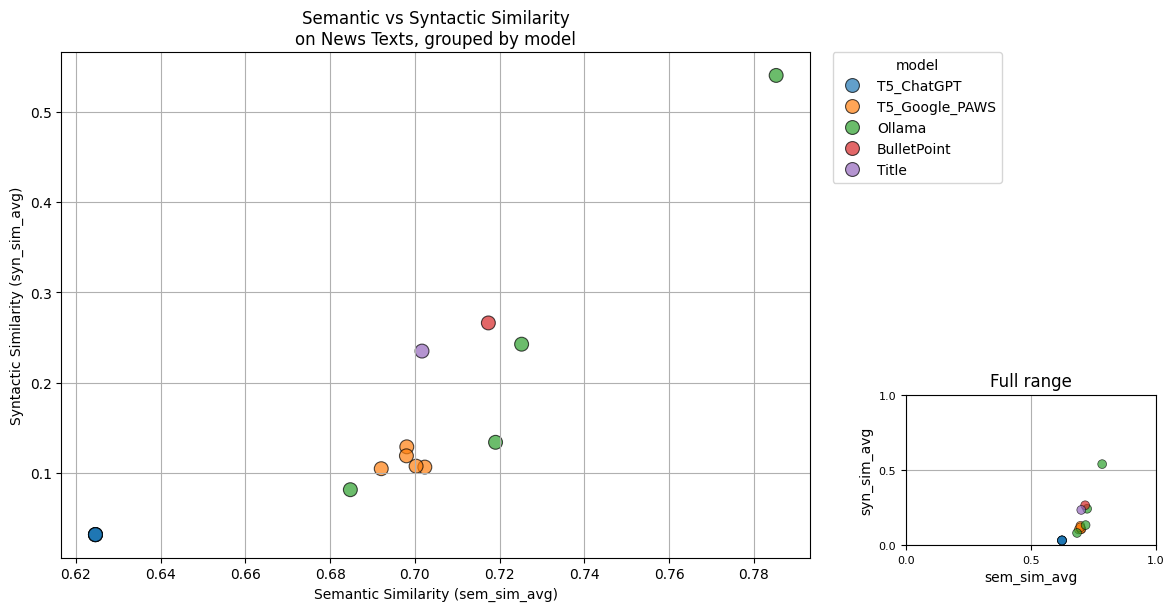

In [15]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1675: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(full_path, bbox_inches="tight")
/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_prompt_20250718_150306.png


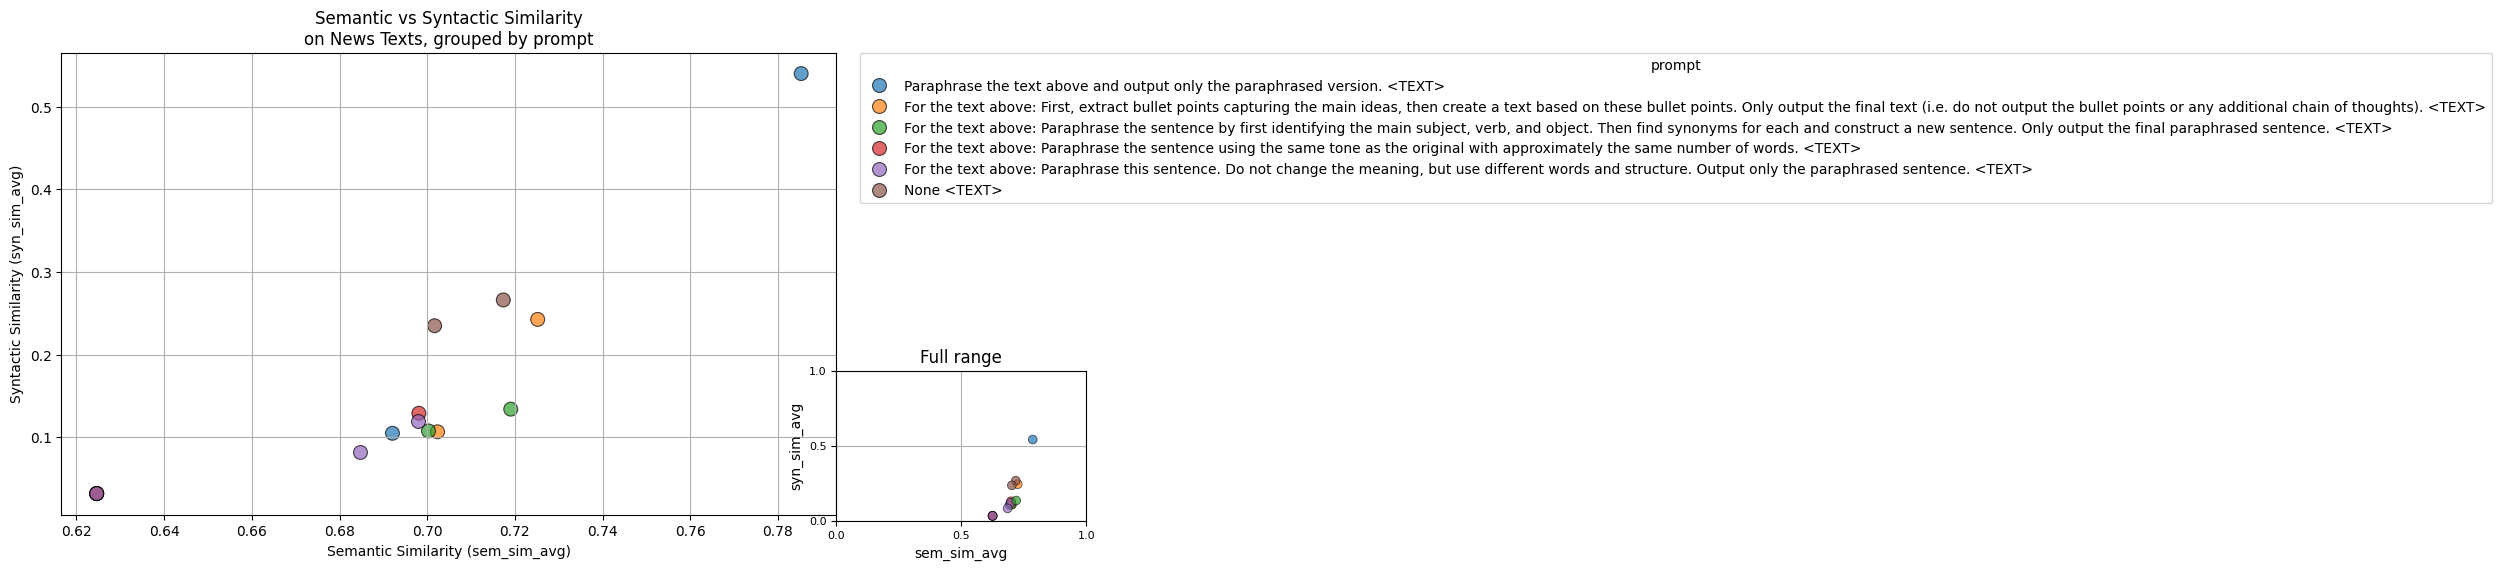

In [16]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

### Kernel Density Estimation (KDE)
- KDE estimates probability density PDF
- The y-axis is density/ concentration/ likelihood, not probability.
- Density can be greater than 1 if data are tightly clustered in a small range.
- For example, if many data points lie very close together, the curve can be sharp and tall (high density), so y-values exceed 1.
- The important property is that the **integral (area) under the curve is 1**, not that the max height is ≤1.

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1734: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1734: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1734: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:1734: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Dev

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_model_20250718_150307.png


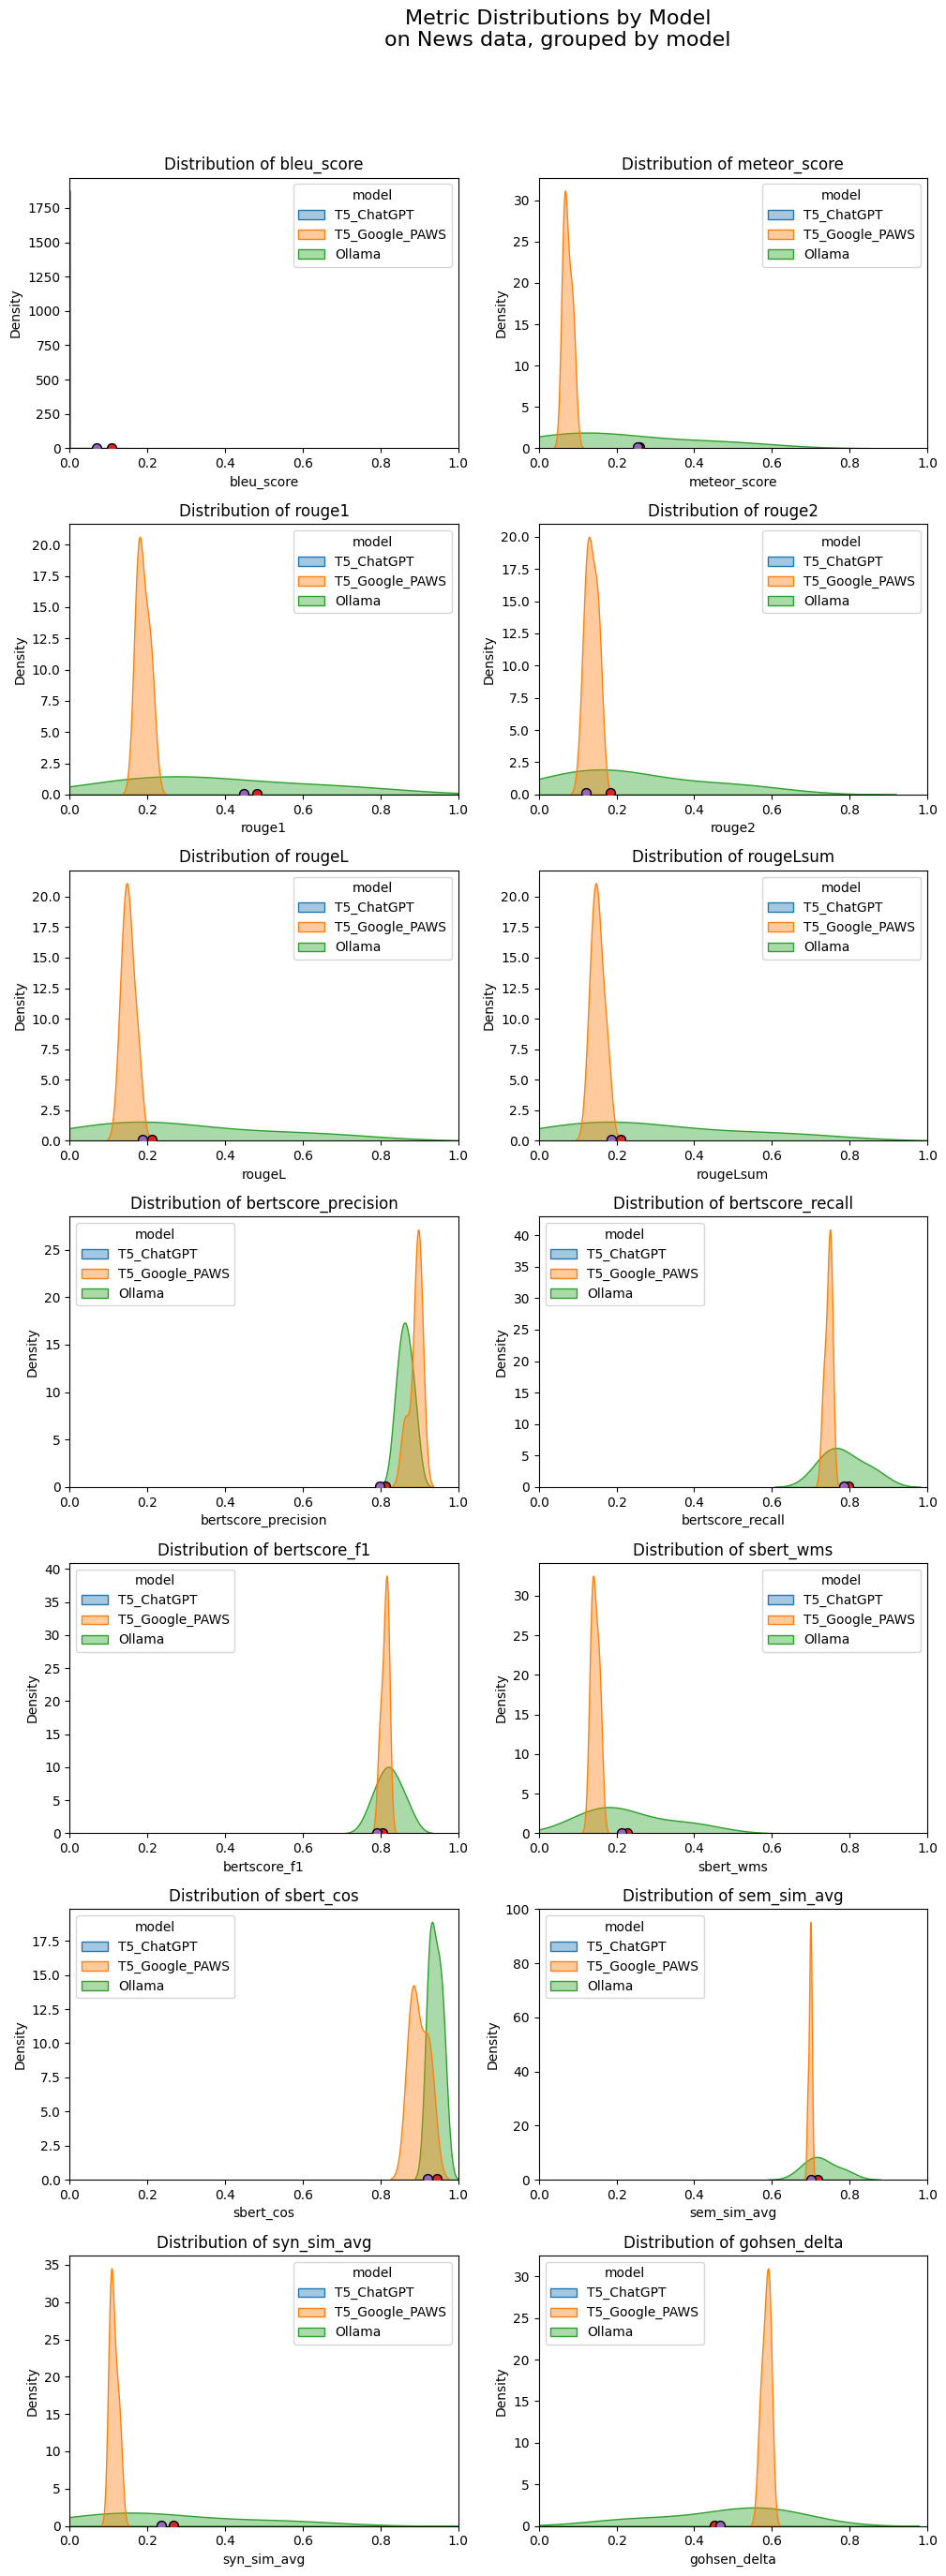

In [17]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_prompt_20250718_150309.png


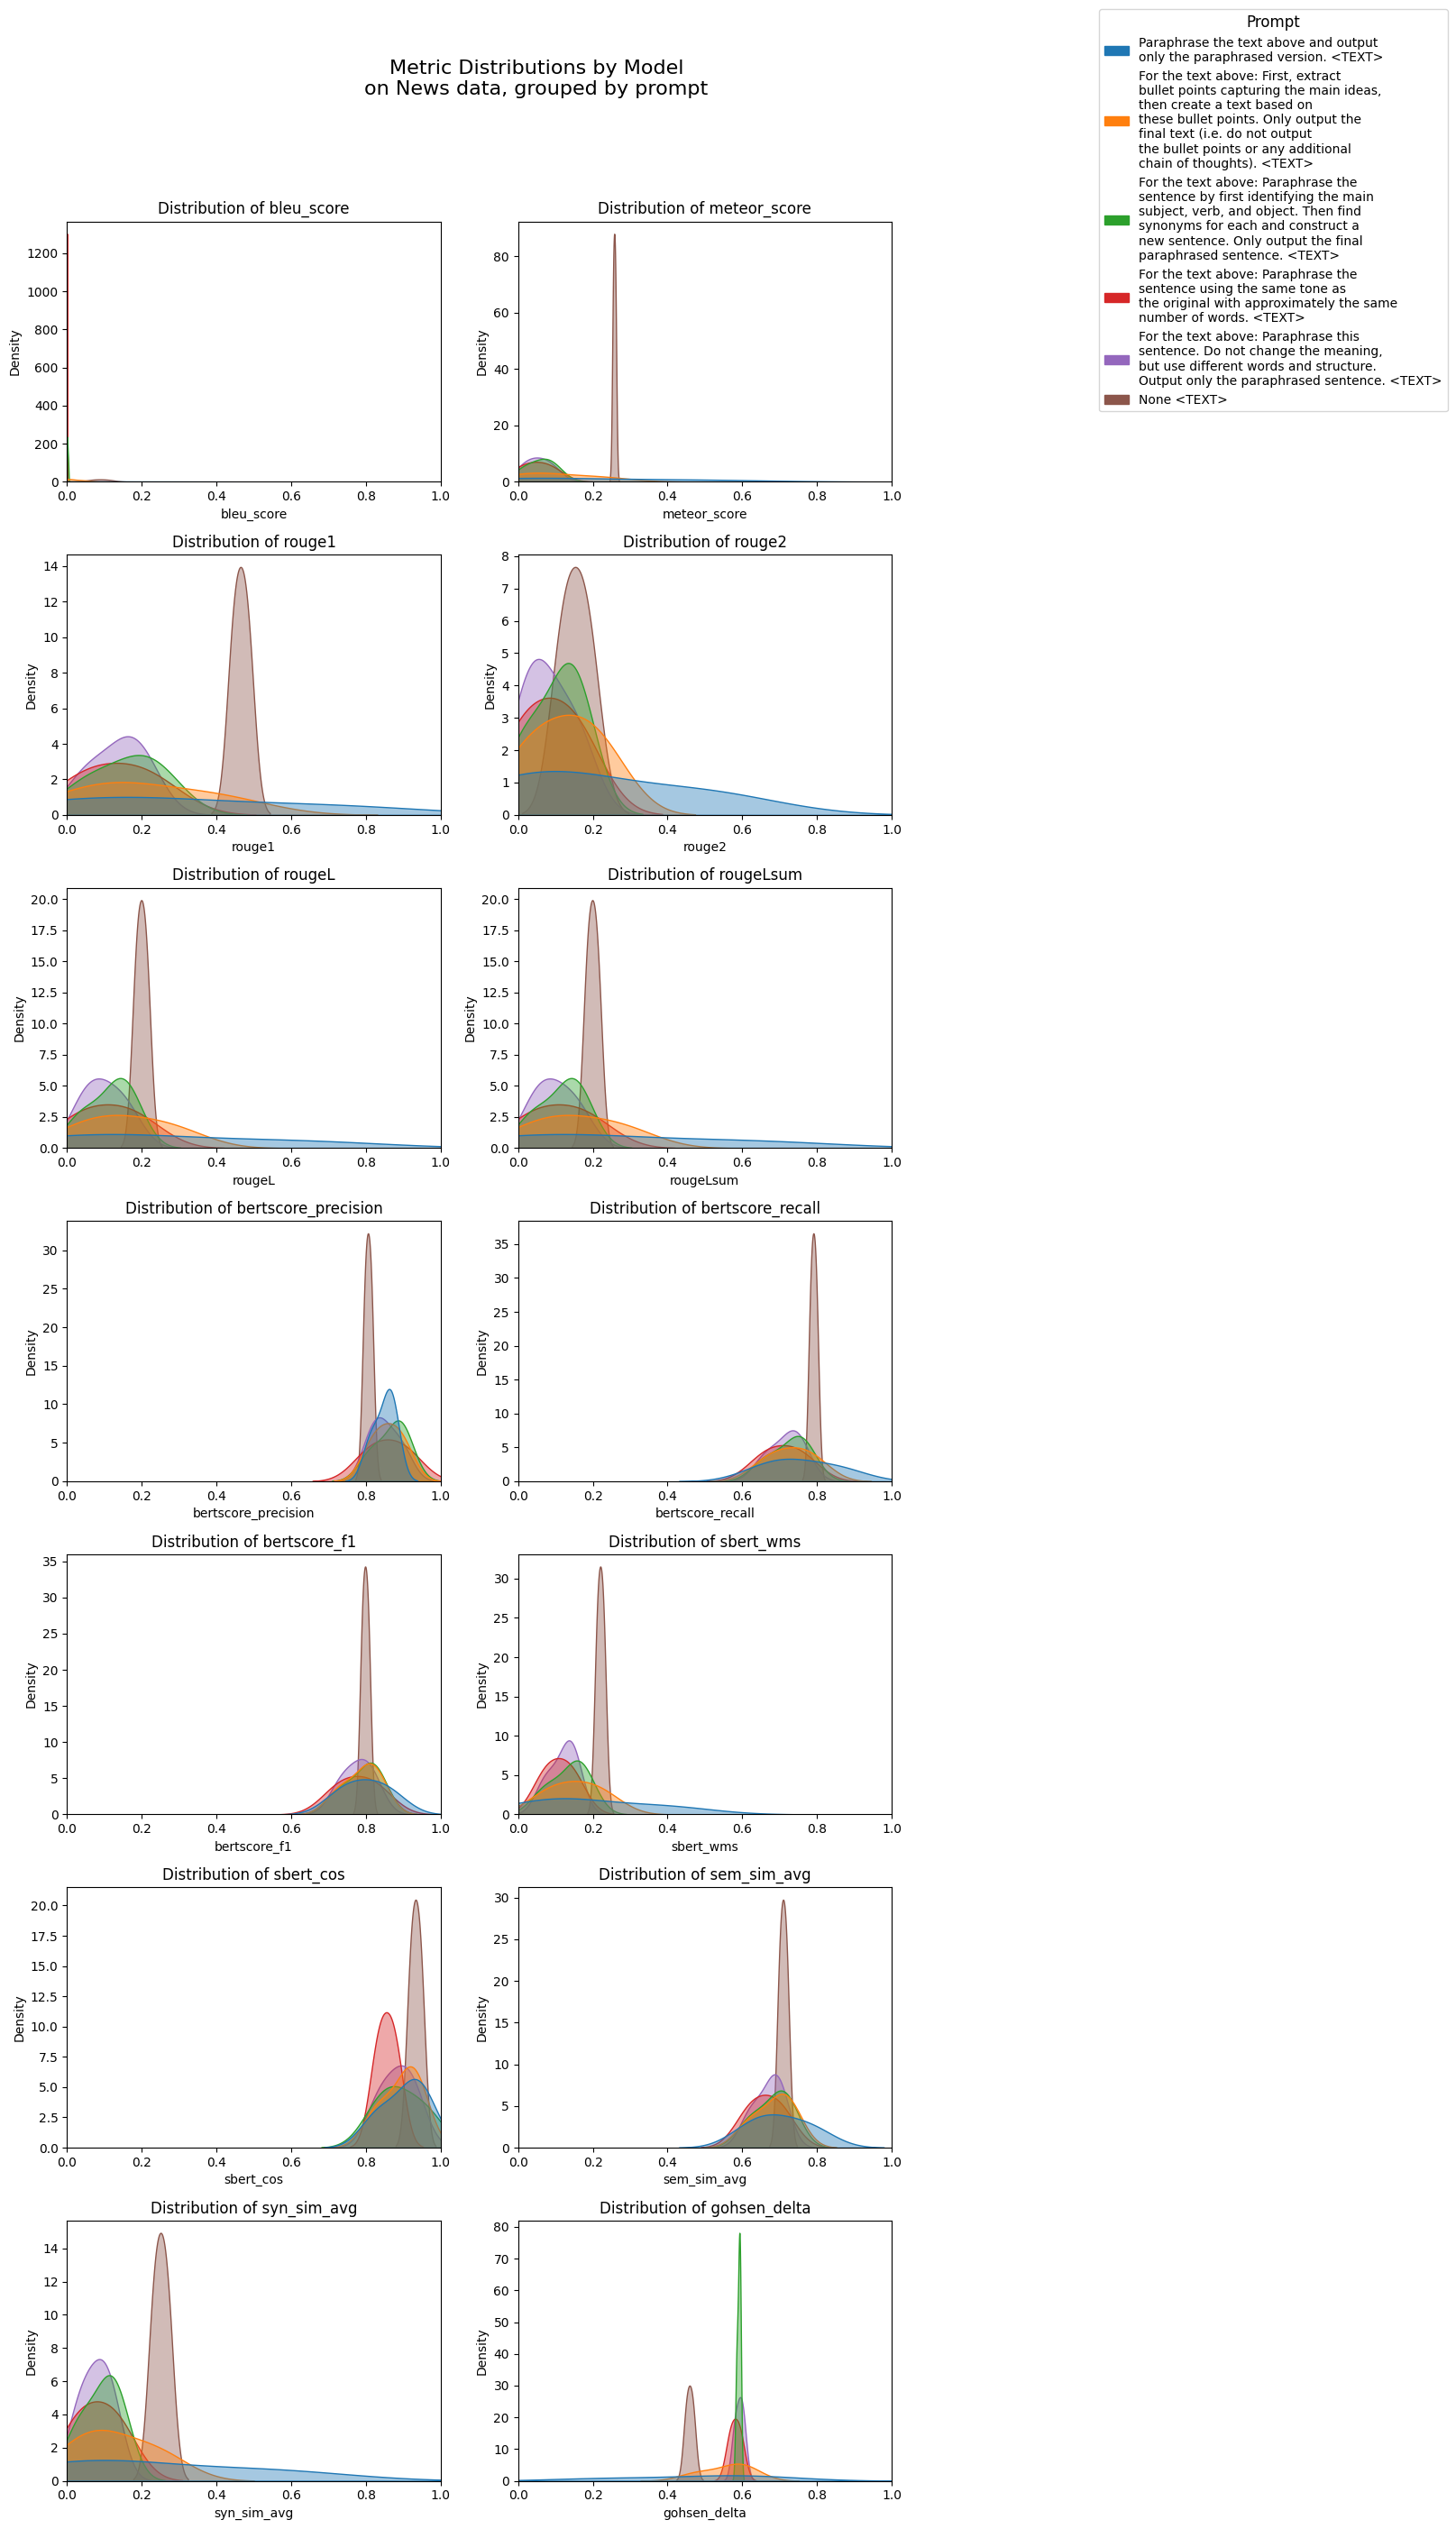

In [18]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

## Batch Processing

In [19]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [20]:
import dirtyjson

d = dirtyjson.loads(
    """["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk"""
)
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]